# 02 — Modelado Predictivo

**Objetivo:** Entrenar y evaluar modelos que expliquen el precio de Equipo 1 y Equipo 2 a partir de las materias primas.

---

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.append('../src')

from modeling import split_data, train_linear_model, evaluate_model, get_feature_importance

PROCESSED_PATH = Path('../data/processed')
print('Librerías y módulos cargados.')

Librerías y módulos cargados.


## 1. Carga de Datos Procesados



In [38]:
df = pd.read_csv(PROCESSED_PATH / "historico_equipos_limpio.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Dataset procesado cargado correctamente")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Periodo: {df['Date'].min().date()} → {df['Date'].max().date()}")

df.head()

Dataset procesado cargado correctamente
Filas: 3,530
Columnas: 6
Periodo: 2010-01-04 → 2023-08-31


,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.12,527.5,2225.25,434.73,931.73
1,2010-01-05,80.59,527.5,2246.50,449.97,968.56
2,2010-01-06,81.89,527.5,2302.50,444.48,960.51
3,2010-01-07,81.51,527.5,2306.50,440.90,960.14
4,2010-01-08,81.37,552.5,2261.25,448.82,949.55


## 2. Preparación de Variables (X, y)

In [39]:
# Variables predictoras
FEATURES = [
    "Price_X",
    "Price_Y",
    "Price_Z"
]

# Objetivos
TARGET_EQUIPO1 = "Price_Equipo1"
TARGET_EQUIPO2 = "Price_Equipo2"


## 3. Entrenamiento de Modelos — Equipo 1

In [40]:
from modeling import (
    time_series_split_data,
    train_linear_model,
    evaluate_model
)

# =====================================================
# DIVISIÓN TEMPORAL - EQUIPO 1
# =====================================================

X_train_eq1, X_test_eq1, y_train_eq1, y_test_eq1, train_df_eq1, test_df_eq1 = (
    time_series_split_data(
        df=df,
        feature_cols=FEATURES,
        target_col=TARGET_EQUIPO1,
        test_size=0.2
    )
)

print("Entrenamiento:", len(X_train_eq1))
print("Prueba:", len(X_test_eq1))

# =====================================================
# MODELO LINEAL - EQUIPO 1
# =====================================================

modelo_equipo1 = train_linear_model(
    X_train_eq1,
    y_train_eq1,
    model_type="linear"
)

metricas_equipo1 = evaluate_model(
    modelo_equipo1,
    X_test_eq1,
    y_test_eq1
)

print("\nMétricas Equipo 1")
print(metricas_equipo1)

print(
    f"Train: {train_df_eq1['Date'].min().date()} -> "
    f"{train_df_eq1['Date'].max().date()}"
)

print(
    f"Test: {test_df_eq1['Date'].min().date()} -> "
    f"{test_df_eq1['Date'].max().date()}"
)

Entrenamiento: 2824
Prueba: 706

Métricas Equipo 1
{'RMSE': np.float64(10.3088), 'MAE': 8.8699, 'R2': 0.9913}
Train: 2010-01-04 -> 2020-12-07
Test: 2020-12-08 -> 2023-08-31


In [41]:
std_features = X_train_eq1.std()

importancia_equipo1 = pd.DataFrame({
    "Variable": FEATURES,
    "Coeficiente": modelo_equipo1.coef_,
    "Importancia": np.abs(
        modelo_equipo1.coef_ * std_features.values
    )
})

importancia_equipo1["Importancia_%"] = (
    importancia_equipo1["Importancia"]
    / importancia_equipo1["Importancia"].sum()
    * 100
)

importancia_equipo1 = importancia_equipo1.sort_values(
    "Importancia",
    ascending=False
)

## 4. Entrenamiento de Modelos — Equipo 2

In [42]:
from modeling import (
    time_series_split_data,
    train_linear_model,
    evaluate_model
)

# División temporal
X_train_eq2, X_test_eq2, y_train_eq2, y_test_eq2, train_df_eq2, test_df_eq2 = (
    time_series_split_data(
        df=df,
        feature_cols=FEATURES,
        target_col=TARGET_EQUIPO2,
        test_size=0.2
    )
)

print("Entrenamiento:", len(X_train_eq2))
print("Prueba:", len(X_test_eq2))

# Modelo lineal
modelo_equipo2 = train_linear_model(
    X_train_eq2,
    y_train_eq2,
    model_type="linear"
)

metricas_equipo2 = evaluate_model(
    modelo_equipo2,
    X_test_eq2,
    y_test_eq2
)

print("\nMétricas Equipo 2")
print(metricas_equipo2)

print(
    f"Train: {train_df_eq2['Date'].min().date()} -> "
    f"{train_df_eq2['Date'].max().date()}"
)

print(
    f"Test: {test_df_eq2['Date'].min().date()} -> "
    f"{test_df_eq2['Date'].max().date()}"
)

Entrenamiento: 2824
Prueba: 706

Métricas Equipo 2
{'RMSE': np.float64(19.3198), 'MAE': 16.5514, 'R2': 0.9853}
Train: 2010-01-04 -> 2020-12-07
Test: 2020-12-08 -> 2023-08-31


In [43]:
print(type(X_train_eq2))
print(X_train_eq2.shape)

<class 'pandas.DataFrame'>
(2824, 3)


In [44]:
std_features = X_train_eq2.std()

importancia_equipo2 = pd.DataFrame({
    "Variable": FEATURES,
    "Coeficiente": modelo_equipo2.coef_,
    "Importancia": np.abs(
        modelo_equipo2.coef_ * std_features.values
    )
})

importancia_equipo2["Importancia_%"] = (
    importancia_equipo2["Importancia"]
    / importancia_equipo2["Importancia"].sum()
    * 100
)

importancia_equipo2 = importancia_equipo2.sort_values(
    "Importancia",
    ascending=False
)

display(importancia_equipo2)

,Variable,Coeficiente,Importancia,Importancia_%
2,Price_Z,0.332109,88.722715,66.473832
1,Price_Y,0.332841,35.580095,26.657720
0,Price_X,0.341043,9.167328,6.868449


Los coeficientes crudos del Equipo 2 parecían similares (0.341, 0.333, 0.332), pero esa aparente igualdad era un artefacto de las distintas escalas de las materias primas. Al estandarizar la importancia (|coef × desviación estándar|), **Price_Z resulta la variable dominante** del precio del Equipo 2.

Conclusión:
Este resultado es coherente con el análisis exploratorio, donde Price_Z presentó la mayor correlación con el Equipo 2 (0.983), y con la importancia de variables de Gradient Boosting (0.80). Por tanto, no se trata de una contribución equilibrada: Price_Z es el principal driver de costo del Equipo 2.


## 5. Comparación de Modelos

In [45]:
# =====================================================
# COMPARACIÓN DE MODELOS FINALES
# =====================================================
#
# Objetivo:
# Comparar el desempeño de los modelos seleccionados
# para cada equipo.
#
# Se utilizan las métricas:
# - RMSE
# - MAE
# - R²
#
# Los modelos seleccionados serán utilizados en la
# fase de forecasting.
# =====================================================

comparacion_modelos = pd.DataFrame([
    {
        "Equipo": "Equipo 1",
        "Modelo": "Regresión Lineal",
        "RMSE": metricas_equipo1["RMSE"],
        "MAE": metricas_equipo1["MAE"],
        "R2": metricas_equipo1["R2"]
    },
    {
        "Equipo": "Equipo 2",
        "Modelo": "Regresión Lineal",
        "RMSE": metricas_equipo2["RMSE"],
        "MAE": metricas_equipo2["MAE"],
        "R2": metricas_equipo2["R2"]
    }
])

display(comparacion_modelos)

,Equipo,Modelo,RMSE,MAE,R2
0,Equipo 1,Regresión Lineal,10.3088,8.8699,0.9913
1,Equipo 2,Regresión Lineal,19.3198,16.5514,0.9853


### Hallazgos

- La regresión lineal obtuvo un desempeño sobresaliente para ambos equipos.
- El modelo explica más del 98% de la variabilidad observada en los precios históricos.
- Las materias primas seleccionadas capturan adecuadamente el comportamiento de los precios de los equipos.
- Los resultados sugieren una relación predominantemente lineal entre las materias primas y los precios finales.

### Modelo seleccionado

La regresión lineal obtuvo un desempeño sobresaliente para ambos equipos (R² > 0.98), demostrando que las materias primas explican gran parte de la variabilidad observada. Debido a su interpretabilidad y precisión, se adopta como modelo explicativo de referencia para el análisis de drivers de costo.

## 6. Diagnóstico del Modelo Lineal

In [46]:
##Predicciones 
## para equipo 1 
pred_equipo1 = modelo_equipo1.predict(X_test)

##para equipo 2 

pred_equipo2 = modelo_equipo2.predict(X_test)

In [47]:
##Calcular residuos
##Equipo 1:
residuos_equipo1 = y_test - pred_equipo1


##Equipo 2:

residuos_equipo2 = y_test - pred_equipo2


In [48]:
##Revisar estadísticas
residuos_equipo1.describe()

count    706.000000
mean     512.070446
std      103.089360
min      317.199277
25%      445.197708
50%      504.910793
75%      552.324851
max      960.420069
Name: Price_Equipo2, dtype: float64

In [49]:
print(type(y_test))
print(y_test.name)

print(y_test.name)

print(pred_equipo1[:5])

print(residuos_equipo1[:5])

<class 'pandas.Series'>
Price_Equipo2
Price_Equipo2
[506.08725795 506.11984468 521.231223   527.16314436 527.07730359]
2824    401.502742
2825    412.230155
2826    387.878777
2827    376.886856
2828    410.492696
Name: Price_Equipo2, dtype: float64


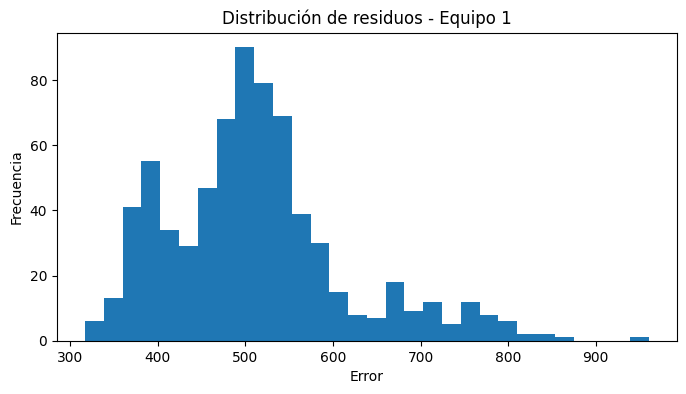

In [50]:
##Histograma
plt.figure(figsize=(8,4))

plt.hist(
    residuos_equipo1,
    bins=30
)

plt.title(
    "Distribución de residuos - Equipo 1"
)

plt.xlabel("Error")
plt.ylabel("Frecuencia")

plt.show()

### Equipo 1

Los resultados muestran una relación altamente consistente entre las materias primas y el costo del Equipo 1.

Resultados relevantes:

- R² del modelo lineal: 0.9913
- RMSE: 10.3088
- MAE: 8.8699
- Variable con mayor coeficiente: Price_Y

Se concluye que Price_Y es la materia prima con mayor influencia sobre el comportamiento histórico del Equipo 1.

### Equipo 2

Los resultados muestran una relación altamente consistente entre las materias primas y el costo del Equipo 2.

Resultados relevantes:

- R² del modelo lineal: 0.9853
- RMSE: 19.3198
- MAE: 16.5514
- Variable con mayor importancia (estandarizada): Price_Z.

Aunque los coeficientes sin estandarizar parecen similares, al ajustar por la escala de cada materia prima Price_Z resulta la de mayor influencia, en línea con la correlación más alta del EDA (0.983) y la importancia de Gradient Boosting (0.80).

### Conclusión General

Las materias primas contienen suficiente información para explicar y anticipar los costos históricos de adquisición de los equipos.

Los modelos de regresión lineal lograron explicar más del 98% de la variabilidad observada para ambos equipos:

- Equipo 1: R² = 0.9913
- Equipo 2: R² = 0.9853

Estos resultados indican que existe una relación predominantemente lineal entre los precios de las materias primas y los costos de los equipos.

Por su precisión, interpretabilidad y simplicidad, la regresión lineal fue seleccionada como el modelo principal para la fase de forecasting.